# Project 3 — Wholesale Customers Segmentation (Advanced)

**Business problem:** A wholesale distributor sells products across several categories
(Fresh, Milk, Grocery, Frozen, Detergents & Paper, Delicatessen) to many client businesses
(restaurants, cafes, retailers). The distributor wants to segment its clients by **annual
spending pattern** to plan inventory, offer bulk discounts, and assign account managers.

This project is more advanced than Project 1: **more features (6 instead of 2)**, **skewed
data that needs a log-transform**, and a discussion of **which linkage/distance combo works best**.

> **Note on data:** This notebook generates a **synthetic dataset shaped like the well-known
> UCI "Wholesale customers" dataset** (6 annual spend categories in monetary units), since this
> environment has no internet access. **If you have the real `Wholesale_customers_data.csv`**,
> replace the "Generate synthetic data" cell with `df = pd.read_csv('Wholesale customers data.csv')`
> and the rest of the notebook works unchanged (column names: Fresh, Milk, Grocery, Frozen,
> Detergents_Paper, Delicassen).


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

np.random.seed(7)
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Generate / Load the Dataset

In [2]:
# ---- Synthetic data generation mimicking real wholesale spending patterns ----
# Real wholesale spend data is typically highly right-skewed (a few big clients spend A LOT),
# so we simulate it with a log-normal distribution -- exactly like the real dataset behaves.

n = 300
categories = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# 3 underlying client "archetypes" -- e.g., restaurants (heavy Fresh/Frozen), retailers (heavy
# Grocery/Detergents_Paper), and cafes (balanced, smaller overall spend)
archetypes = {
    'restaurant': {'Fresh': 9.5, 'Milk': 7.0, 'Grocery': 7.2, 'Frozen': 8.8, 'Detergents_Paper': 5.5, 'Delicassen': 7.0},
    'retailer':   {'Fresh': 7.5, 'Milk': 8.5, 'Grocery': 9.8, 'Frozen': 6.0, 'Detergents_Paper': 9.0, 'Delicassen': 6.5},
    'cafe':       {'Fresh': 6.5, 'Milk': 7.5, 'Grocery': 6.8, 'Frozen': 5.5, 'Detergents_Paper': 5.0, 'Delicassen': 6.0},
}
archetype_names = list(archetypes.keys())

rows = []
for _ in range(n):
    arch = np.random.choice(archetype_names, p=[0.4, 0.35, 0.25])
    means = archetypes[arch]
    row = {}
    for cat in categories:
        # log-normal spend: exp(normal) -> right-skewed, always positive, realistic for money data
        row[cat] = int(np.exp(np.random.normal(means[cat], 0.6)))
    rows.append(row)

df = pd.DataFrame(rows, columns=categories)
df.head()


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,11021,2628,1416,45276,222,921
1,3329,7046,12391,363,10972,568
2,20936,1043,1397,5428,413,1166
3,35969,1203,1061,22414,238,459
4,3462,873,1783,9509,371,375


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.describe()


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,7674.286667,2833.963333,7822.546667,3495.616667,3276.226667,872.286667
std,9596.554122,2696.998473,12531.153075,5088.307530,5411.861823,705.123494
min,211.000000,254.000000,179.000000,45.000000,44.000000,112.000000
25%,1030.500000,1037.000000,905.750000,277.000000,163.750000,450.250000
50%,3148.000000,1895.500000,1700.000000,688.000000,329.500000,690.000000
75%,11710.250000,3639.000000,11746.750000,5502.000000,5291.250000,1034.500000
max,58412.000000,15550.000000,104571.000000,45276.000000,36218.000000,6510.000000


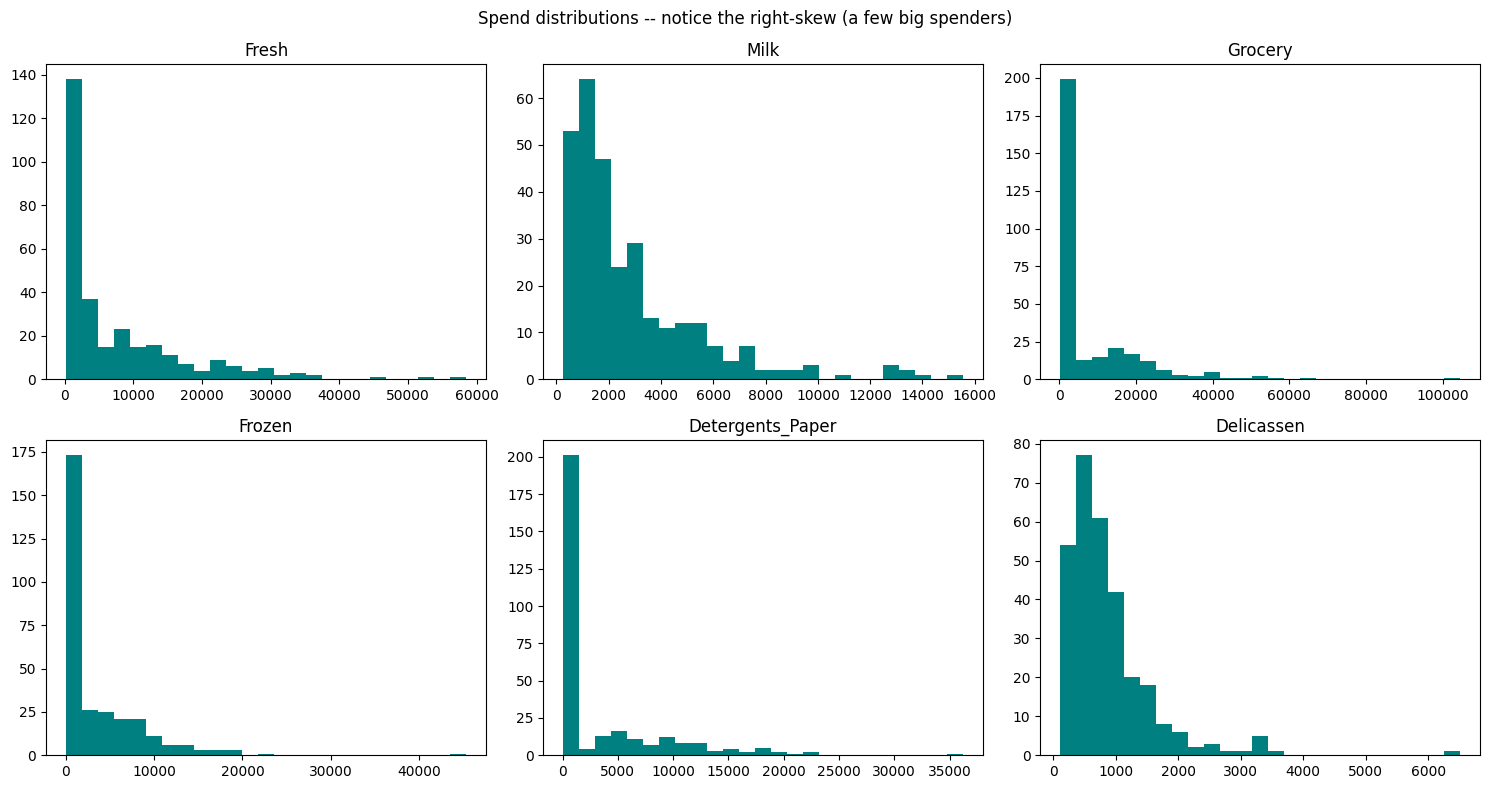

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, cat in zip(axes, categories):
    ax.hist(df[cat], bins=25, color='teal')
    ax.set_title(cat)
plt.suptitle('Spend distributions -- notice the right-skew (a few big spenders)')
plt.tight_layout()
plt.show()


**Real-life note:** Wholesale/monetary data is almost always right-skewed like this. A handful of large clients spend far more than the typical client, which can distort Euclidean distances. That's why the next step matters.

## 4. Preprocessing — Log Transform + Scaling

Since spend values are skewed and span a wide range, we first apply a **log transform**
(`log(1+x)`) to compress large values, then standardize. This is standard practice for any
monetary/count data before distance-based clustering.

In [5]:
df_log = np.log1p(df[categories])  # log1p = log(1+x), safely handles any zero values too

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log)
print("Scaled shape:", X_scaled.shape)


Scaled shape: (300, 6)


## 5. PCA for Visualization

Variance explained by 2 components: 0.788


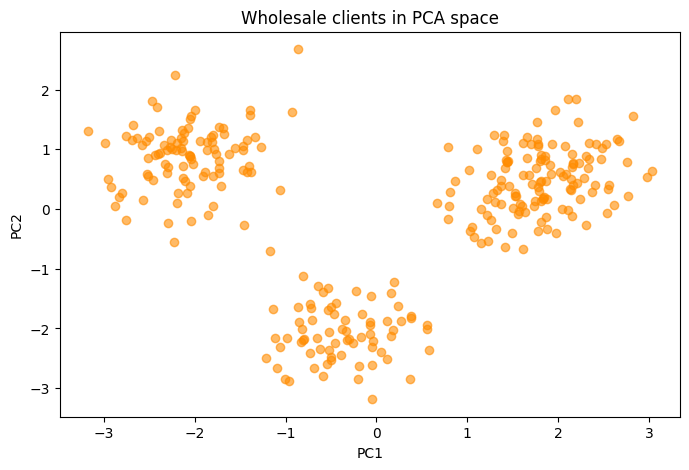

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='darkorange')
plt.title('Wholesale clients in PCA space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## 6. Dendrogram — Compare Linkage Methods

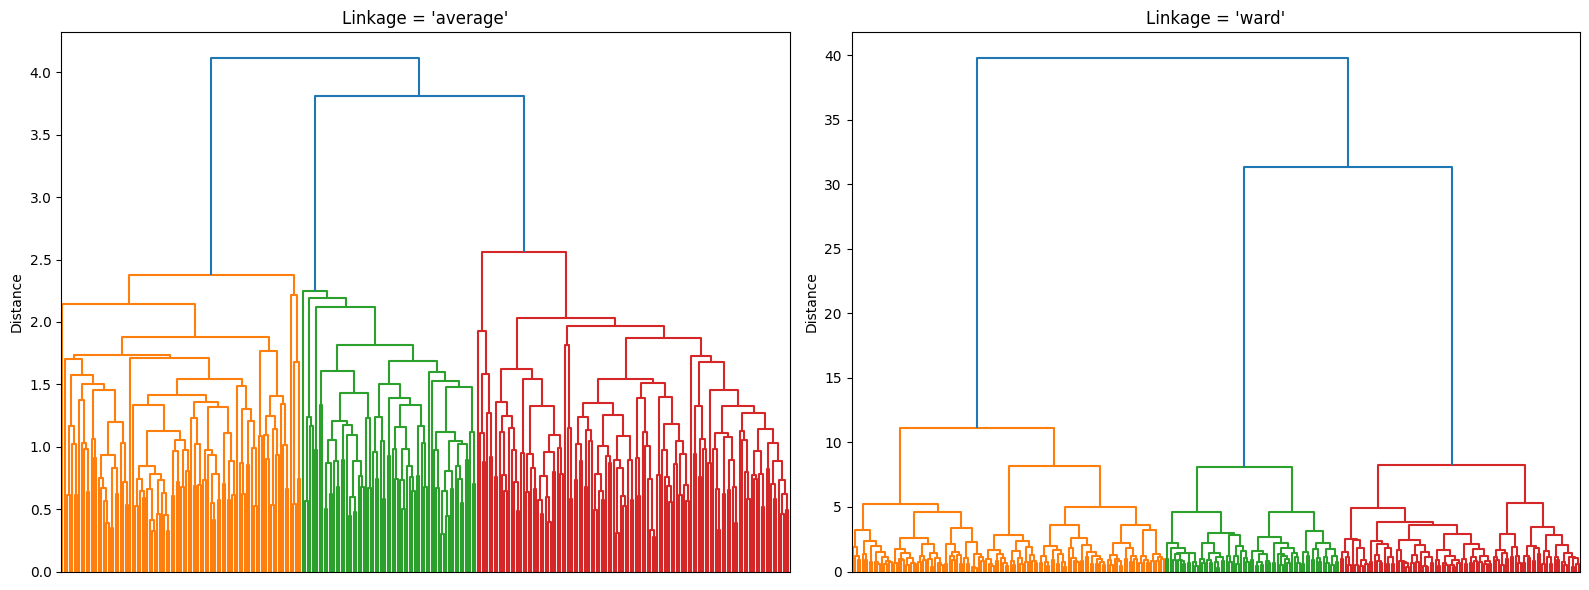

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, m in zip(axes, ['average', 'ward']):
    Z = linkage(X_scaled, method=m)
    dendrogram(Z, ax=ax, no_labels=True)
    ax.set_title(f"Linkage = '{m}'")
    ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()


In [8]:
Z = linkage(X_scaled, method='ward')
merge_distances = Z[:, 2]
gaps = np.diff(merge_distances)
best_gap_index = np.argmax(gaps)
suggested_k = len(merge_distances) - best_gap_index
print(f"Suggested number of clusters (longest-gap trick): {suggested_k}")


Suggested number of clusters (longest-gap trick): 3


## 7. Apply Agglomerative Clustering

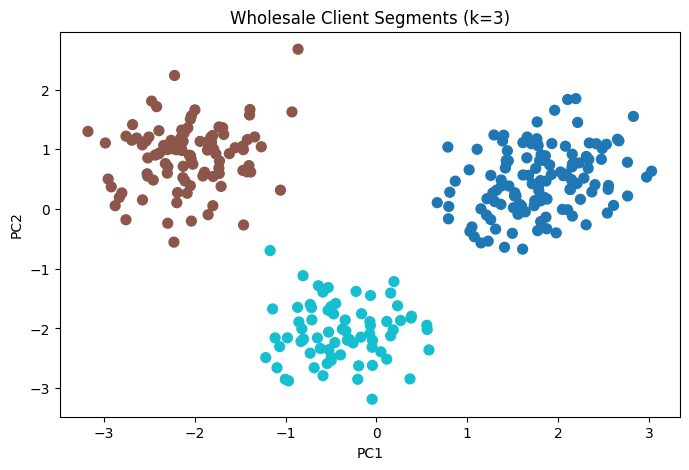

Silhouette score: 0.523


In [9]:
K = 3  # matches our 3 simulated business archetypes; also cross-check against dendrogram above

model = AgglomerativeClustering(n_clusters=K, metric='euclidean', linkage='ward')
df['cluster'] = model.fit_predict(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='tab10', s=50)
plt.title(f'Wholesale Client Segments (k={K})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

print("Silhouette score:", round(silhouette_score(X_scaled, df['cluster']), 3))


## 8. Business Interpretation

In [10]:
cluster_profile = df.groupby('cluster')[categories].mean().round(0)
cluster_profile['NumClients'] = df.groupby('cluster').size()
cluster_profile


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,NumClients
cluster,,,,,,,
0,15673.0,1236.0,1507.0,7618.0,323.0,1220.0,129
1,2261.0,5440.0,20982.0,455.0,9393.0,731.0,99
2,786.0,2114.0,1043.0,291.0,157.0,444.0,72


**How a real analyst would read this table:**
- A cluster with high `Fresh` + `Frozen`, moderate everything else → likely **restaurants** (need frequent fresh/frozen delivery — prioritize cold-chain logistics for them).
- A cluster with high `Grocery` + `Detergents_Paper` → likely **retailers/supermarkets** (bulk shelf-stable goods — offer bulk discounts & scheduled restocking).
- A cluster with balanced, moderate spend across categories → likely **cafes/small businesses** (smaller, flexible orders — good candidates for loyalty/subscription plans).

This is exactly the kind of insight that lets a distributor **customize logistics, pricing, and account management per segment** instead of treating every client the same.

## 9. Try It Yourself

- Try clustering WITHOUT the log-transform and compare — does skew hurt the results?
- Try `linkage='average'` with `metric='cosine'` — since we care about *spending proportions*, not just totals, cosine similarity can sometimes reveal cleaner client "profiles."
- Increase `K` to 4 or 5 and see if any cluster naturally splits into a more specific sub-segment.
